# Holographic Axicon Beam Study

Stage C notebook for the `slm_plane -> fourier_filter_plane -> objective_pupil_plane -> surface_plane` holographic route. The blaze carrier separates diffraction orders; first-order filtering happens in the Fourier/filter plane before objective-pupil clipping and focusing.

In [27]:
from dataclasses import replace
from pathlib import Path

import pandas as pd

import bessel_twin_core as bt
from vbb_study import setup_study, vbb_regime, vbb_train_viz
from vbb_study.equations import objective_pupil as objp
from vbb_study.publication import lab_realism as lab_schema

PATHS = setup_study.bootstrap(Path.cwd())
PRESET = "fast"
RUN_ID = PATHS.get("run_id") or None
base = replace(bt.default_config(PRESET), generation_method="holographic")
out_fig = PATHS["figures"] / "stage_c"
out_csv = PATHS["csv"] / "stage_c"
out_fig.mkdir(parents=True, exist_ok=True)
out_csv.mkdir(parents=True, exist_ok=True)

def _objective_fields(cfg):
    return {
        "objective_NA": float(cfg.objective.NA),
        "objective_f_eff_mm": float(cfg.objective.f_eff_m / bt.mm),
        "pupil_radius_mm": float(cfg.objective.pupil_radius_m / bt.mm),
        "pupil_clipped_fraction": objp.gaussian_clipping_power_fraction(
            cfg.laser.beam_radius_on_slm_m,
            cfg.objective.pupil_radius_m,
        ),
    }

def _hardware_status(path_label):
    return "current_lab_realizable" if path_label == "lab" else "simulation_only"


## Editable Notebook Controls

<!-- STAGE88: editable controls -->

This cell exposes the intended user-editable controls for exploratory runs. The locked stage logic below is preserved: changing these controls is for local investigation unless the notebook explicitly wires a value into a regenerated canonical output. Keep QA, caveats, and fail/marginal labels visible. For fast beam-to-sample exploration use the quicklook notebook; for publication-grade outputs use the locked stage runner.


In [28]:
# STAGE88: visible editable controls for exploratory notebook use.
# Edit NOTEBOOK_CONTROLS below and re-run this cell to apply parameter
# overrides to `base` before running any study cell below.
from vbb_study.publication import notebook_controls as nb_controls
from vbb_study.config import um as _um

NOTEBOOK_CONTROLS = nb_controls.make_notebook_controls(
    stage='lab_realism',
    # ── edit these to override the base configuration ───────────────────────
    ell=3,
    target_core_diameter_um=3.0,
    target_bessel_length_um=150.0,
    objective_NA=0.45,
    blaze_period_px=20,
)

# Wire control parameters into `base` so downstream cells use them.
_p = NOTEBOOK_CONTROLS.parameters or {}
if "ell" in _p:
    base = replace(base, target=replace(base.target, ell=int(_p["ell"])))
if "target_core_diameter_um" in _p:
    base = replace(base, target=replace(base.target, target_core_diameter_m=float(_p["target_core_diameter_um"]) * _um))
if "target_bessel_length_um" in _p:
    base = replace(base, target=replace(base.target, target_bessel_length_m=float(_p["target_bessel_length_um"]) * _um))
if "objective_NA" in _p:
    base = replace(base, objective=replace(base.objective, NA=float(_p["objective_NA"])))
if "blaze_period_px" in _p:
    base = replace(base, slm=replace(base.slm, blaze_period_px=int(_p["blaze_period_px"])))

try:
    display(nb_controls.describe_controls(NOTEBOOK_CONTROLS))
except NameError:
    print(nb_controls.describe_controls(NOTEBOOK_CONTROLS).to_string(index=False))


,control,value
0,stage,lab_realism
1,run_mode,balanced
2,save_outputs,False
3,use_canonical_outputs,True
4,allow_publication_export,False
5,notes,Edit for exploration; keep QA labels/caveats v...
6,ell,3
7,target_core_diameter_um,3.0
8,target_bessel_length_um,150.0
9,objective_NA,0.45


In [29]:
# Interactive quicklook — adjust sliders and click "Update plots".
# Runs a fast preview only; nothing is saved.
from vbb_study.publication import notebook_widgets as nbw

_panel = nbw.interactive_quicklook(base, method='holographic', preset='fast')
display(_panel)


In [30]:
rows = []
for regime in ("general", "limits"):
    cfg = vbb_regime.config_for_regime(base, regime)
    for label, path_name in [("ideal", "ideal"), ("lab", "realistic")]:
        result = bt.run_case(cfg, preset=PRESET, path=path_name, case_id=f"{regime}_holographic_{label}")
        m = result["metrics"]
        row = {
            "case_id": f"{regime}_holographic_{label}",
            "regime": regime,
            "path": path_name,
            "route_variant": label,
            "canonical_zone_um": m["canonical_zone_um"],
            "strict_bessel_region_um": m["strict_bessel_region_um"],
            "feature_diameter_um": m["feature_diameter_um"],
            "peak_fluence_J_cm2": m["peak_fluence_J_cm2"],
            "side_to_core_peak_ratio": m["side_to_core_peak_ratio"],
            "first_order_selected_fraction": m.get("first_order_selected_fraction"),
            "propagation_power_drift_fraction": m.get("propagation_power_drift_fraction"),
            "propagation_power_label": m.get("propagation_power_label"),
            "validity_valid": result["validity_report"]["valid"],
            **_objective_fields(cfg),
        }
        lab_schema.annotate_lab_realism_row(
            row,
            generation_method="holographic_axicon",
            model_level="lab_realistic" if label == "lab" else "ideal_target",
            hardware_status=_hardware_status(label),
            plane_label="surface_plane",
            coordinate_frame="surface_plane_air_um",
            run_id=RUN_ID,
            preset=PRESET,
            path=path_name,
        )
        rows.append(row)
summary = lab_schema.ordered_lab_realism_frame(rows)
summary.to_csv(out_csv / "holographic_axicon_route_summary.csv", index=False)
summary


,run_id,generated_at_utc,source_schema_version,case_id,preset,path,generation_method,model_level,hardware_status,plane_label,...,propagation_power_label,canonical_zone_um,strict_bessel_region_um,qa_status,regime,route_variant,feature_diameter_um,peak_fluence_J_cm2,side_to_core_peak_ratio,validity_valid
0,20260616T175027Z,2026-06-16T17:50:27.428238+00:00,1.0.0,general_holographic_ideal,fast,ideal,holographic_axicon,ideal_target,simulation_only,surface_plane,...,fail,116.406260,103.125,exploratory,general,ideal,5.277632,2.674508,0.429279,True
1,20260616T175029Z,2026-06-16T17:50:29.529598+00:00,1.0.0,general_holographic_lab,fast,realistic,holographic_axicon,lab_realistic,current_lab_realizable,surface_plane,...,fail,38.015567,0.000,exploratory,general,lab,3.270841,4.718381,0.376263,True
2,20260616T175031Z,2026-06-16T17:50:31.672825+00:00,1.0.0,limits_holographic_ideal,fast,ideal,holographic_axicon,ideal_target,simulation_only,surface_plane,...,fail,114.468843,75.000,exploratory,limits,ideal,3.267105,3.149295,0.476238,True
3,20260616T175033Z,2026-06-16T17:50:33.868893+00:00,1.0.0,limits_holographic_lab,fast,realistic,holographic_axicon,lab_realistic,current_lab_realizable,surface_plane,...,marginal,249.745519,0.000,exploratory,limits,lab,4.776797,0.605325,1.000000,True


In [31]:
delta = summary.pivot(
    index="regime",
    columns="path",
    values=[
        "canonical_zone_um",
        "feature_diameter_um",
        "peak_fluence_J_cm2",
        "side_to_core_peak_ratio",
    ],
)
delta


canonical_zone_um             feature_diameter_um            \
path                ideal   realistic               ideal realistic   
regime                                                                
general        116.406260   38.015567            5.277632  3.270841   
limits         114.468843  249.745519            3.267105  4.776797   

        peak_fluence_J_cm2           side_to_core_peak_ratio            
path                 ideal realistic                   ideal realistic  
regime                                                                  
general           2.674508  4.718381                0.429279  0.376263  
limits            3.149295  0.605325                0.476238  1.000000

WindowsPath('C:/PhD/Code/Publication_Study/outputs/figures/stage_c/stage_c_sampling_qa_limits.png')

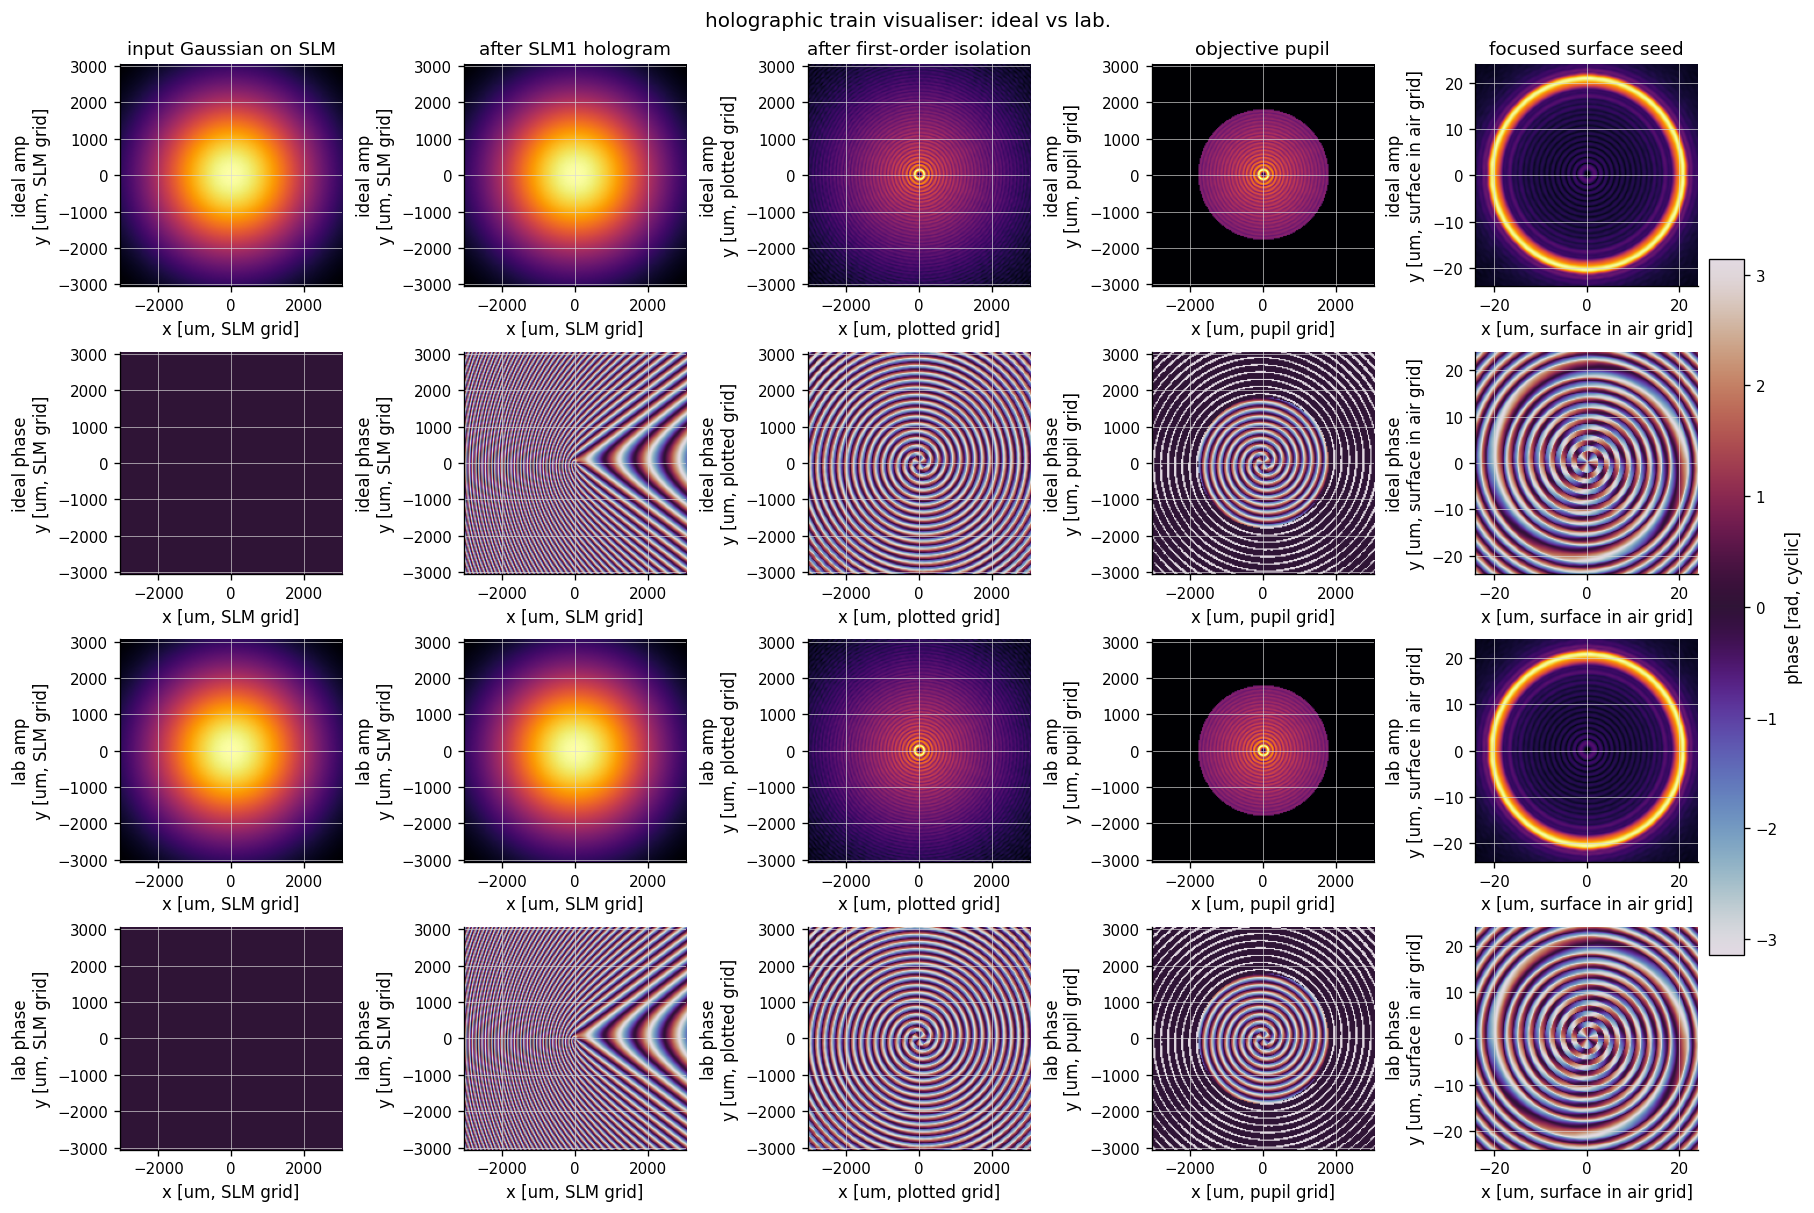

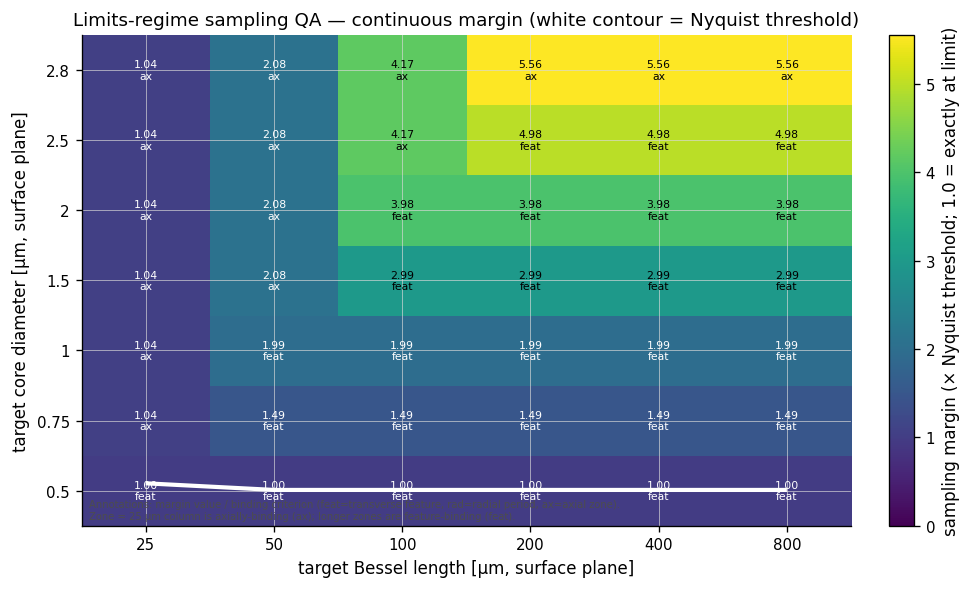

In [32]:
vbb_train_viz.plot_train_visualiser(base, method='holographic', output_dir=out_fig)
vbb_train_viz.plot_sampling_qa(base, output_dir=out_fig)

## Stage C.5 carrier/filter fairness sweep

Bounded nominal ell=3 sweep of blaze period and filter radius. The chosen point maximises first-order selected fraction while keeping zero-order leakage below the stated threshold and avoiding a capped canonical zone.

,run_id,generated_at_utc,source_schema_version,case_id,preset,path,generation_method,model_level,hardware_status,plane_label,...,zero_order_leakage_dc_fraction,bessel_zone_um,zone_capped,first_order_geometry_valid,phase_sampling_label,focal_sampling_label,validity_valid,surface_z_um,is_eligible_optimum,is_optimum
0,20260616T175155Z,2026-06-16T17:51:55.039178+00:00,1.0.0,carrier_px18_filter6p00,fast,realistic,holographic_axicon,hardware_route,current_lab_realizable,fourier_filter_plane,...,0.034511,35.211526,False,True,pass,pass,True,-55.562596,True,True


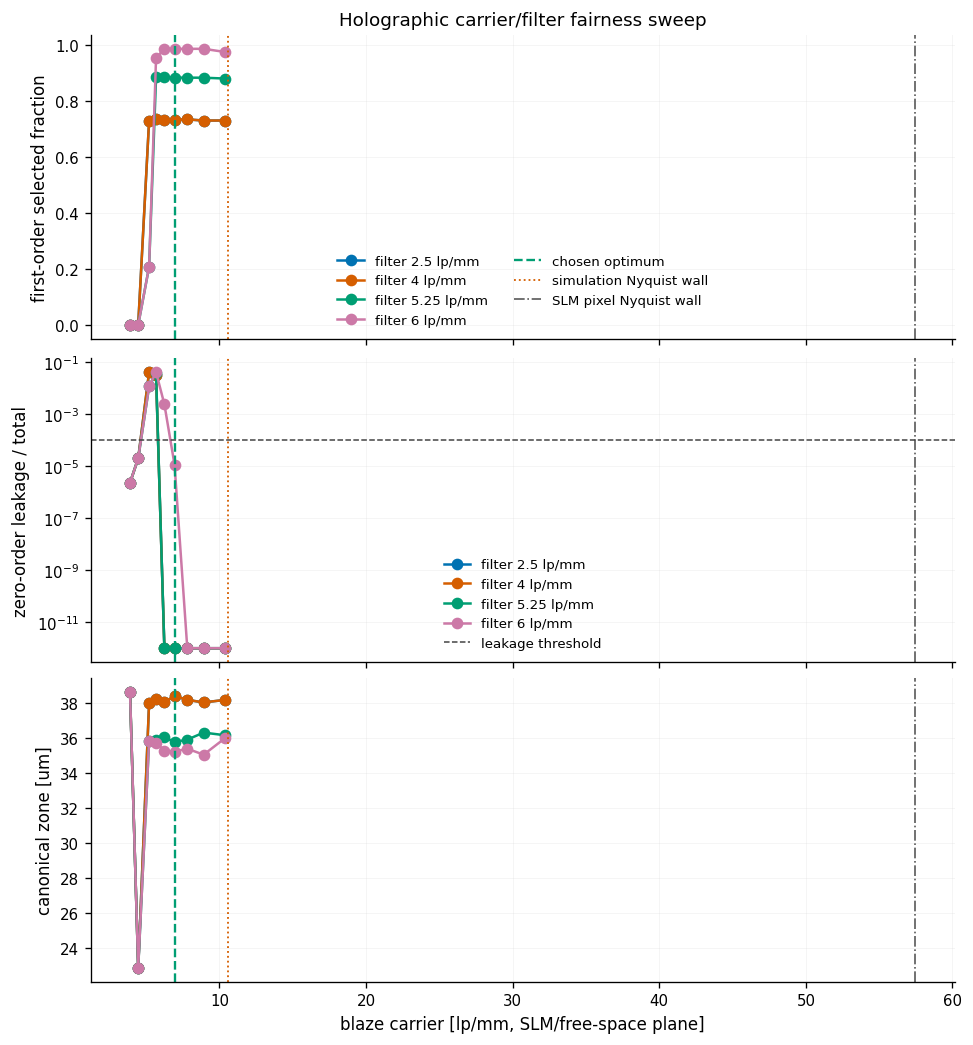

In [33]:
# Fourier/filter-plane carrier and first-order stop sweep.
carrier_sweep = vbb_train_viz.holographic_carrier_filter_sweep(base)
carrier_sweep["case_id"] = [
    f"carrier_px{int(row.blaze_period_px)}_filter{float(row.configured_filter_radius_lpmm):.2f}".replace(".", "p")
    for row in carrier_sweep.itertuples()
]
carrier_sweep = lab_schema.with_lab_realism_metadata(
    carrier_sweep,
    generation_method="holographic_axicon",
    model_level="hardware_route",
    hardware_status="current_lab_realizable",
    plane_label="fourier_filter_plane",
    coordinate_frame="fourier_filter_plane_spatial_frequency_lpmm",
    run_id=RUN_ID,
    preset=PRESET,
    path="realistic",
)
carrier_sweep.to_csv(out_csv / "holographic_first_order_filter_sweep.csv", index=False)
vbb_train_viz.plot_holographic_carrier_filter_tradeoff(carrier_sweep, base, output_dir=out_fig)
carrier_sweep.loc[carrier_sweep["is_optimum"]].reset_index(drop=True)


In [34]:
# Fair rerun: use the optimized holographic carrier/filter in the method comparison.
optimum = carrier_sweep.loc[carrier_sweep["is_optimum"]].iloc[0]
optimised_base = replace(
    base,
    slm=replace(
        base.slm,
        blaze_period_px=int(optimum["blaze_period_px"]),
        first_order_filter_radius_lpmm=float(optimum["configured_filter_radius_lpmm"]),
    ),
)
fair_raw = vbb_train_viz.method_comparison_table(
    optimised_base,
    regimes=("general",),
    methods=("holographic", "physical"),
)
rows = []
for row in fair_raw.to_dict("records"):
    method = str(row.get("method", "")).lower()
    lab_schema.annotate_lab_realism_row(
        row,
        generation_method="physical_axicon" if method == "physical" else "holographic_axicon",
        model_level="hardware_route",
        hardware_status="future_hardware_required" if method == "physical" else "current_lab_realizable",
        plane_label="surface_plane",
        coordinate_frame="surface_plane_air_um",
        run_id=RUN_ID,
        preset=PRESET,
        path=str(row.get("path", "realistic")),
    )
    rows.append(row)
fair_comparison = lab_schema.ordered_lab_realism_frame(rows)
fair_comparison.to_csv(out_csv / "holographic_optimised_method_comparison.csv", index=False)
fair_comparison


,run_id,generated_at_utc,source_schema_version,preset,path,generation_method,model_level,hardware_status,plane_label,coordinate_frame,...,method,bessel_zone_um,feature_diameter_um,peak_fluence_J_cm2,side_to_core_peak_ratio,throughput_or_efficiency,realised_k_r_m_inv,slm2_residual_before_rad,slm2_residual_after_rad,validity_valid
0,20260616T175200Z,2026-06-16T17:52:00.064573+00:00,1.0.0,fast,realistic,holographic_axicon,hardware_route,current_lab_realizable,surface_plane,surface_plane_air_um,...,holographic,35.211526,3.801189,5.275187,0.305576,0.987891,1.603333e+06,NaN,NaN,True
1,20260616T175200Z,2026-06-16T17:52:00.064594+00:00,1.0.0,fast,ideal,physical_axicon,hardware_route,future_hardware_required,surface_plane,surface_plane_air_um,...,physical,113.937100,4.775000,14.381208,0.539002,0.950288,1.603333e+06,1.813817,0.007127,True
